# Week 4 - Univariate Analysis, part 2

# 1. Lesson - None

# 2. Weekly graph question

Below are a histogram and boxplot representation of the same data. A pharmacy is keeping a record of the prices of the drugs that it sells, and an administrator wants to know how much the more expensive drugs tend to cost, in the context of the other prices.

Please write a short explanation of the pros and cons of these two representations. Which would you choose? How would you modify the formatting, if at all, to make it more visually interesting, clear, or informative?

In [2]:
import numpy as np
import pandas as pd

np.random.seed(0)
num_data = 100
data = np.exp(np.random.uniform(size = num_data) * 4)
df = pd.DataFrame(data.T, columns = ["data"])

The 75th percentile is: data    15.457656
Name: 0.75, dtype: float64


<Axes: ylabel='Frequency'>

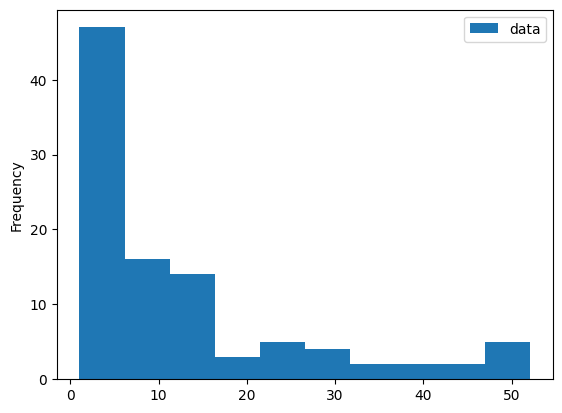

In [3]:
print("The 75th percentile is:", df.quantile(q = 0.75))
df.plot.hist()

<Axes: >

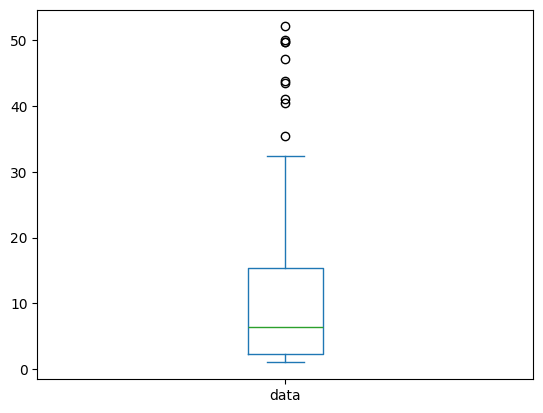

In [4]:
df.plot.box()

A histogram is great for seeing the overall shape of the distribution (skewness, clusters, gaps) and how often different price ranges occur, but the interpretation depends on the bin width and extreme values can be less obvious. A boxplot quickly summarizes the median, quartiles (IQR), spread, and outliers, which makes it easy to identify unusually expensive drugs, but it hides detailed distribution shape. For a pharmacy administrator focused on “how expensive drugs tend to be,” I would prioritize the boxplot (to flag outliers and typical range) and also include the histogram for context. To improve clarity, I’d add a clear title and axis labels, remove the legend (only one variable), choose an appropriate bin count, and mark the median/75th percentile; if prices are very right-skewed, I’d consider a log scale.

# 3. Homework - working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Draw histograms and histogram variants for each feature or column.  (Swarm plot, kde plot, violin plot).

- Draw grouped histograms.  For instance, if you have tree heights for both maple and oak trees, you could draw histograms for both.

- Draw a bar plot to indicate total counts of each categorical variable in a given column.

- Find means, medians, and modes.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If they are not useable, find some new data!

- What is the overall shape of the distribution?  Is it normal, skewed, bimodal, uniform, etc.?

- Are there any outliers present?  (Data points that are far from the others.)

- If there are multiple related histograms, how does the distribution change across different groups?

- What are the minimum and maximum values represented in each histogram?

- How do bin sizes affect the histogram?  Does changing the bin width reveal different patterns in the data?

- Does the distribution appear normal, or does it have a different distribution?

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

cancer_path = "archive/cancer_data_eng.csv"
df = pd.read_csv(cancer_path, encoding="latin1", low_memory=False)

print("Shape:", df.shape)
df.head()


Shape: (1778176, 38)


,Patient.Code,RCBP.Name,Gender,Date.of.Birth,Age,Raca.Color,Nationality,Naturality.State,Naturality,Degree.of.Education,...,Laterality,Statement,TNM,Status.Vital,Type.of.Death,Date.of.Death,Date.of.Last.Contact,Date.of.Diagnostic,Distant.metastasis,year
0,672054.0,RCBP CAMPINAS-UNICAMP,MASCULINO,1975-03-16,30.0,BRANCO,BRASIL,SÃO PAULO,NaN,NaN,...,NaN,NaN,NaN,MORTO,CÂNCER,2005-10-07,2005-10-07,2005-10-07,NaN,2005.0
1,673213.0,RCBP CAMPINAS-UNICAMP,FEMININO,1950-05-24,53.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,MORTO,NaN,2007-01-30,2007-01-30,2003-07-18,NaN,2003.0
2,673396.0,RCBP CAMPINAS-UNICAMP,FEMININO,1951-09-02,51.0,PARDA,BRASIL,SÃO PAULO,NaN,NaN,...,NaN,NaN,NaN,MORTO,CÂNCER,2005-07-03,2005-07-03,2003-05-16,NaN,2003.0
3,673425.0,RCBP CAMPINAS-UNICAMP,FEMININO,1929-11-21,73.0,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,VIVO,NaN,NaN,2010-07-28,2003-04-01,NaN,2003.0
4,673745.0,RCBP CAMPINAS-UNICAMP,MASCULINO,1934-07-03,71.0,BRANCO,BRASIL,SÃO PAULO,NaN,NaN,...,NaN,NaN,NaN,MORTO,CÂNCER,2005-10-21,2005-10-21,2005-10-21,NaN,2005.0


In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1778176 entries, 0 to 1778175
Data columns (total 38 columns):
 #   Column                           Dtype  
---  ------                           -----  
 0   Patient.Code                     float64
 1   RCBP.Name                        object 
 2   Gender                           object 
 3   Date.of.Birth                    object 
 4   Age                              float64
 5   Raca.Color                       object 
 6   Nationality                      object 
 7   Naturality.State                 object 
 8   Naturality                       object 
 9   Degree.of.Education              object 
 10  State.Civil                      object 
 11  Code.Profession                  float64
 12  Name.Occupation                  object 
 13  Status.Address                   object 
 14  City.Address                     object 
 15  Description.of.Topography        object 
 16  Topography.Code                  object 
 17  Morpholo

In [7]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Patient.Code,1703747.0,NaN,NaN,NaN,711348.153805,335610.156559,101.0,448323.5,694134.0,940808.5,1464035.0
RCBP.Name,1778176,32,RCBP SÃO PAULO,656882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1778176,3,FEMININO,971471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date.of.Birth,1009731,38114,1940-01-01,184,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1698204.0,NaN,NaN,NaN,60.034357,17.209329,0.0,49.0,62.0,73.0,1067.0
Raca.Color,993128,5,BRANCO,616662,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Nationality,815180,113,BRASIL,811183,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Naturality.State,451556,27,MINAS GERAIS,62170,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Naturality,186412,4425,CAMPINAS,7710,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Degree.of.Education,405828,6,FUNDAMENTAL I (1ª A 4ª SÉRIE),129760,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
missing_count = df.isna().sum().sort_values(ascending=False)
missing_pct = (missing_count / len(df) * 100).round(2)

missing_table = pd.DataFrame({"missing_count": missing_count, "missing_%": missing_pct})
missing_table[missing_table["missing_count"] > 0].head(25)


,missing_count,missing_%
Distant.metastasis,1760809,99.02
TNM,1715988,96.50
Statement,1713701,96.37
Naturality,1591764,89.52
Laterality,1580348,88.87
Status.Vital,1568418,88.20
Type.of.Death,1378897,77.55
Degree.of.Education,1372348,77.18
Date.of.Last.Contact,1335704,75.12
Naturality.State,1326620,74.61


In [9]:
core_cols = [
    "Patient.Code","RCBP.Name","Gender","Age","Raca.Color",
    "Illness.Code","Description.of.Disease",
    "Topography.Code","Description.of.Topography",
    "Code.of.Morphology","Morphology.Description",
    "Diagnostic.means","Date.of.Diagnostic","year"
]

df_core = df[core_cols].copy()
print("df_core shape:", df_core.shape)
df_core.head()


df_core shape: (1778176, 14)


,Patient.Code,RCBP.Name,Gender,Age,Raca.Color,Illness.Code,Description.of.Disease,Topography.Code,Description.of.Topography,Code.of.Morphology,Morphology.Description,Diagnostic.means,Date.of.Diagnostic,year
0,672054.0,RCBP CAMPINAS-UNICAMP,MASCULINO,30.0,BRANCO,C20,RETO,C209,"RETO, SOE",80003,NEOPLASIA MALIGNA,SDO,2005-10-07,2005.0
1,673213.0,RCBP CAMPINAS-UNICAMP,FEMININO,53.0,NaN,C186,COLON DESCENDENTE,C186,COLON DESCENDENTE,82113,ADENOCARCINOMA TUBULAR,HISTOLOGIA DO TUMOR PRIMÁRIO,2003-07-18,2003.0
2,673396.0,RCBP CAMPINAS-UNICAMP,FEMININO,51.0,PARDA,C509,"MAMA , SOE",C509,"MAMA , SOE",85003,CARCINOMA DUCTAL INFILTRANTE,HISTOLOGIA DO TUMOR PRIMÁRIO,2003-05-16,2003.0
3,673425.0,RCBP CAMPINAS-UNICAMP,FEMININO,73.0,NaN,C446,PELE DO MEMBRO SUPERIOR E DO OMBRO,C446,PELE DO MEMBRO SUPERIOR E DO OMBRO,80703,"CARCINOMA DE CELULAS ESCAMOSAS, SOE",HISTOLOGIA DO TUMOR PRIMÁRIO,2003-04-01,2003.0
4,673745.0,RCBP CAMPINAS-UNICAMP,MASCULINO,71.0,BRANCO,C80,LOCALIZACAO PRIMARIA DESCONHECIDA,C809,"LOCALIZACAO PRIMARIA DESCONHECIDA, SOE",80003,NEOPLASIA MALIGNA,SDO,2005-10-21,2005.0


In [10]:
# Patient.Code is an ID: nullable integer
df_core["Patient.Code"] = pd.to_numeric(df_core["Patient.Code"], errors="coerce").astype("Int64")

# Age: numeric
df_core["Age"] = pd.to_numeric(df_core["Age"], errors="coerce")

# Date: datetime
df_core["Date.of.Diagnostic"] = pd.to_datetime(df_core["Date.of.Diagnostic"], errors="coerce")

# Year: numeric; if missing, fill from Date.of.Diagnostic
df_core["year"] = pd.to_numeric(df_core["year"], errors="coerce")
df_core["year"] = df_core["year"].fillna(df_core["Date.of.Diagnostic"].dt.year).astype("Int64")

df_core.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1778176 entries, 0 to 1778175
Data columns (total 14 columns):
 #   Column                     Dtype         
---  ------                     -----         
 0   Patient.Code               Int64         
 1   RCBP.Name                  object        
 2   Gender                     object        
 3   Age                        float64       
 4   Raca.Color                 object        
 5   Illness.Code               object        
 6   Description.of.Disease     object        
 7   Topography.Code            object        
 8   Description.of.Topography  object        
 9   Code.of.Morphology         int64         
 10  Morphology.Description     object        
 11  Diagnostic.means           object        
 12  Date.of.Diagnostic         datetime64[ns]
 13  year                       Int64         
dtypes: Int64(2), datetime64[ns](1), float64(1), int64(1), object(9)
memory usage: 193.3+ MB


In [11]:
dup_rows = df_core.duplicated().sum()
print("Duplicate rows in df_core:", dup_rows)

# Optional removal (only do if dup_rows > 0)
# df_core = df_core.drop_duplicates()


Duplicate rows in df_core: 32481


In [12]:
# Fill Age with median (robust)
df_core["Age"] = df_core["Age"].fillna(df_core["Age"].median())

# Fill key categoricals with UNKNOWN so we don't drop tons of rows
for c in ["Gender", "Raca.Color", "Diagnostic.means", "RCBP.Name"]:
    df_core[c] = df_core[c].fillna("UNKNOWN")

# Quick check after fill
(df_core.isna().mean().sort_values(ascending=False) * 100).head(15)


Patient.Code                 4.185694
Date.of.Diagnostic           3.590308
year                         3.590308
RCBP.Name                    0.000000
Gender                       0.000000
Age                          0.000000
Raca.Color                   0.000000
Illness.Code                 0.000000
Description.of.Disease       0.000000
Topography.Code              0.000000
Description.of.Topography    0.000000
Code.of.Morphology           0.000000
Morphology.Description       0.000000
Diagnostic.means             0.000000
dtype: float64

In [13]:
df_core.describe(include="all").T


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Patient.Code,1703747.0,<NA>,<NA>,<NA>,711348.153805,101.0,448323.5,694134.0,940808.5,1464035.0,335610.156559
RCBP.Name,1778176,32,RCBP SÃO PAULO,656882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1778176,3,FEMININO,971471,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,1778176.0,NaN,NaN,NaN,60.122761,0.0,50.0,62.0,72.0,1067.0,16.822823
Raca.Color,1778176,6,UNKNOWN,785048,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Illness.Code,1778176,536,C61,172979,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description.of.Disease,1778176,513,PROSTATA,174101,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Topography.Code,1778176,387,C619,173832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Description.of.Topography,1778176,387,"PROSTATA, SOE",173832,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Code.of.Morphology,1778176.0,NaN,NaN,NaN,82841.794106,80000.0,80703.0,80973.0,83803.0,99903.0,4273.057773


In [14]:
# Age sanity
print("Age min/max:", df_core["Age"].min(), df_core["Age"].max())
bad_age_mask = (df_core["Age"] < 0) | (df_core["Age"] > 120)
df_core = df_core.loc[~bad_age_mask].copy()

# Date sanity
future_dates = df_core[df_core["Date.of.Diagnostic"] > pd.Timestamp.today()]
print("Future diagnostic dates:", len(future_dates))


Age min/max: 0.0 1067.0
Future diagnostic dates: 0


In [15]:
df_core.duplicated().sum()


np.int64(32535)

In [16]:
# Remove unrealistic ages
df_core = df_core[(df_core["Age"] >= 0) & (df_core["Age"] <= 120)]
print("Shape after removing bad ages:", df_core.shape)


Shape after removing bad ages: (1778152, 14)


In [17]:
df_core = df_core.drop_duplicates()
print("Shape after dropping duplicates:", df_core.shape)


Shape after dropping duplicates: (1745617, 14)


In [18]:
df_core = df_core.copy()  # avoid chained assignment issues

# 1) Fill missing values (do BEFORE filtering)
df_core["Age"] = pd.to_numeric(df_core["Age"], errors="coerce")
df_core["Age"] = df_core["Age"].fillna(df_core["Age"].median())

for c in ["Gender", "Raca.Color", "Diagnostic.means", "RCBP.Name"]:
    df_core[c] = df_core[c].fillna("UNKNOWN")

# 2) Remove unrealistic ages
bad_age_mask = (df_core["Age"] < 0) | (df_core["Age"] > 120)
print("Bad age rows (will remove):", bad_age_mask.sum())
df_core = df_core.loc[~bad_age_mask].copy()

# 3) Drop exact duplicate rows
dup_before = df_core.duplicated().sum()
print("Duplicate rows (will remove):", dup_before)
df_core = df_core.drop_duplicates().copy()

print("Final df_core shape:", df_core.shape)

Bad age rows (will remove): 0
Duplicate rows (will remove): 0
Final df_core shape: (1745617, 14)


In [19]:

print("Missing % (top 10):")
print((df_core.isna().mean().sort_values(ascending=False) * 100).head(10))

print("\nAge min/max:", df_core["Age"].min(), df_core["Age"].max())
print("Duplicate rows remaining:", df_core.duplicated().sum())

future_dates = df_core[df_core["Date.of.Diagnostic"] > pd.Timestamp.today()]
print("Future diagnostic dates:", len(future_dates))


Missing % (top 10):
Patient.Code              2.443663
Date.of.Diagnostic        1.839292
year                      1.839292
RCBP.Name                 0.000000
Gender                    0.000000
Age                       0.000000
Raca.Color                0.000000
Illness.Code              0.000000
Description.of.Disease    0.000000
Topography.Code           0.000000
dtype: float64

Age min/max: 0.0 118.0
Duplicate rows remaining: 0
Future diagnostic dates: 0


In [20]:
# Show missing count 
na_check = pd.DataFrame({
    "missing_count": df_core.isna().sum(),
    "missing_%": (df_core.isna().mean() * 100).round(4)
}).sort_values("missing_%", ascending=False)

na_check


,missing_count,missing_%
Patient.Code,42657,2.4437
Date.of.Diagnostic,32107,1.8393
year,32107,1.8393
RCBP.Name,0,0.0000
Gender,0,0.0000
Age,0,0.0000
Raca.Color,0,0.0000
Illness.Code,0,0.0000
Description.of.Disease,0,0.0000
Topography.Code,0,0.0000


In [21]:
df_core_noNA = df_core.dropna(subset=["Patient.Code", "Date.of.Diagnostic", "year"]).copy()
print("Shape after dropping rows with NA in key cols:", df_core_noNA.shape)
print(df_core_noNA.isna().sum())


Shape after dropping rows with NA in key cols: (1702960, 14)
Patient.Code                 0
RCBP.Name                    0
Gender                       0
Age                          0
Raca.Color                   0
Illness.Code                 0
Description.of.Disease       0
Topography.Code              0
Description.of.Topography    0
Code.of.Morphology           0
Morphology.Description       0
Diagnostic.means             0
Date.of.Diagnostic           0
year                         0
dtype: int64


In [22]:
df_core = df_core_noNA  # Holy so much cleaning, Ask neeza if removing all NA's are appropriate or not
print("Using df_core shape:", df_core.shape)
print(df_core.isna().sum().sum())  


Using df_core shape: (1702960, 14)
0


In [23]:

print("Age mean:", df_core["Age"].mean())
print("Age median:", df_core["Age"].median())
print("Gender mode:", df_core["Gender"].mode()[0])
print("FEMININO is Female in Portuguese")


Age mean: 60.11824470334007
Age median: 62.0
Gender mode: FEMININO
FEMININO is Female in Portuguese


In [24]:
encode_cols = ["Gender", "Raca.Color", "Diagnostic.means"]
df_encoded = pd.get_dummies(df_core, columns=encode_cols, dummy_na=True, drop_first=True)
df_encoded.shape


(1702960, 28)

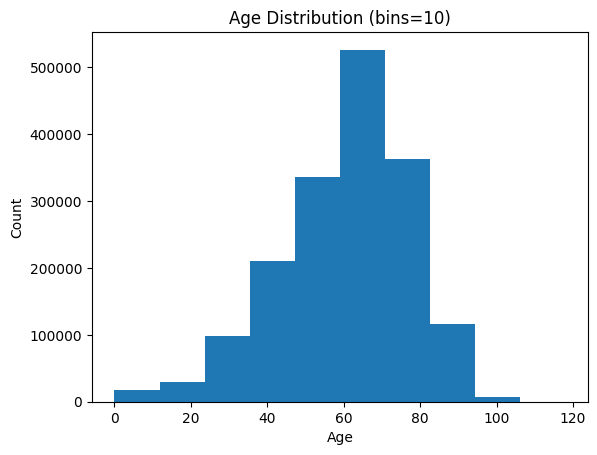

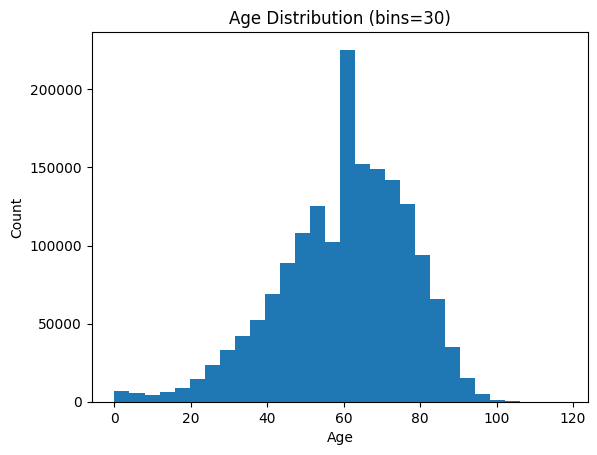

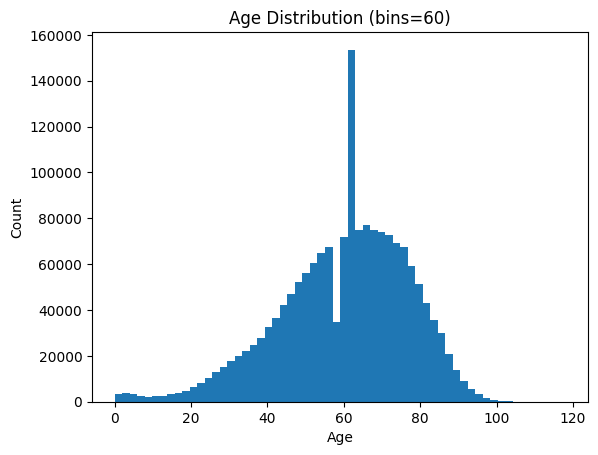

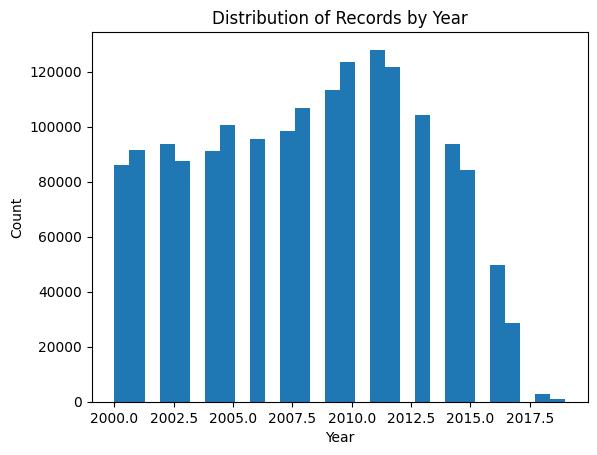

In [25]:
# Age histogram 
for b in [10, 30, 60]:
    plt.figure()
    plt.hist(df_core["Age"], bins=b)
    plt.title(f"Age Distribution (bins={b})")
    plt.xlabel("Age")
    plt.ylabel("Count")
    plt.show()

# Year histogram
plt.figure()
plt.hist(df_core["year"], bins=30)
plt.title("Distribution of Records by Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()


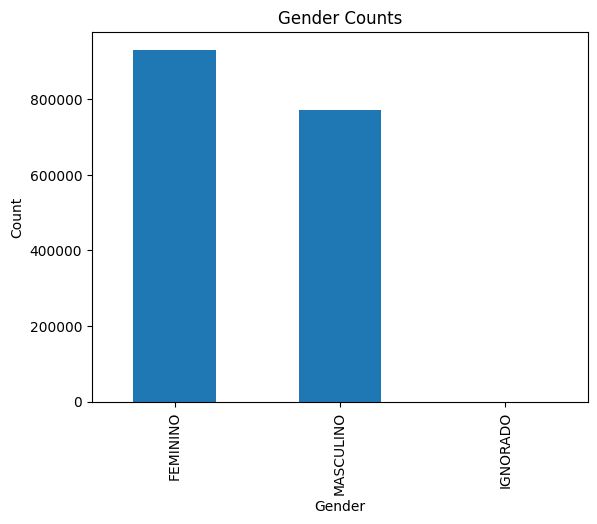

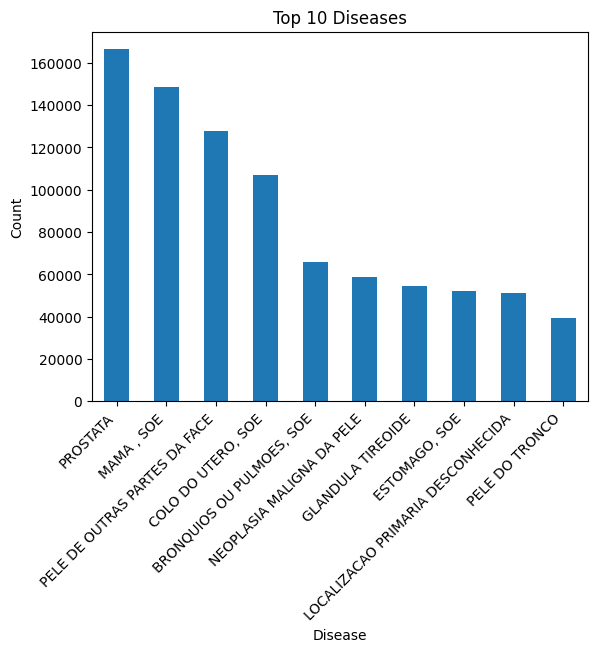

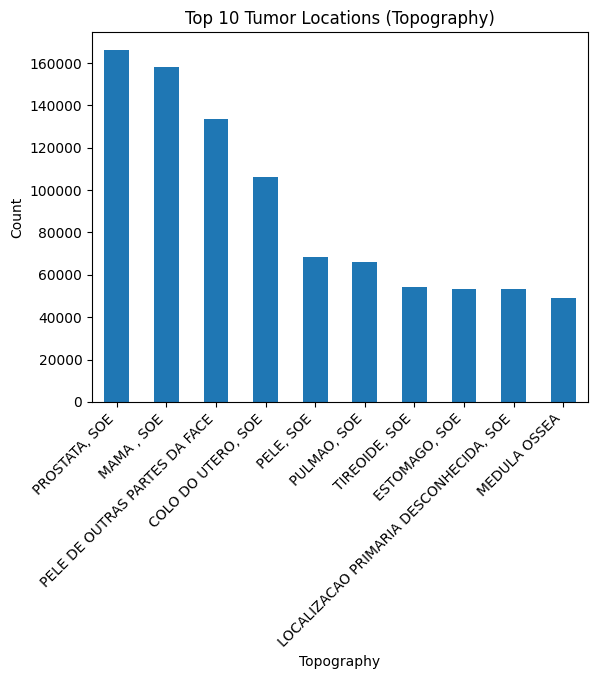

In [26]:
# Gender bar plot
plt.figure()
df_core["Gender"].value_counts().plot(kind="bar")
plt.title("Gender Counts")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

# Top 10 diseases
plt.figure()
df_core["Description.of.Disease"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Diseases")
plt.xlabel("Disease")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()

# Topography (top 10)
plt.figure()
df_core["Description.of.Topography"].value_counts().head(10).plot(kind="bar")
plt.title("Top 10 Tumor Locations (Topography)")
plt.xlabel("Topography")
plt.ylabel("Count")
plt.xticks(rotation=45, ha="right")
plt.show()


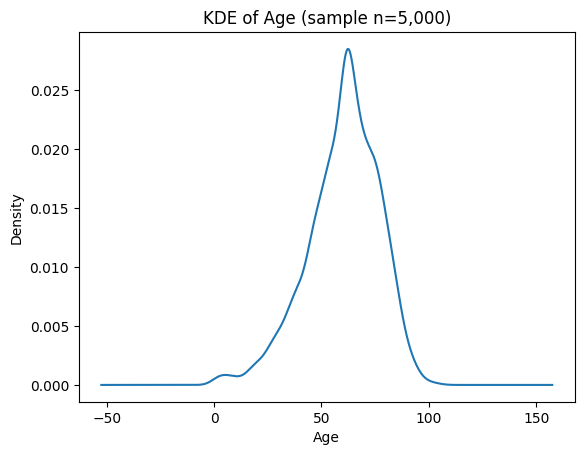

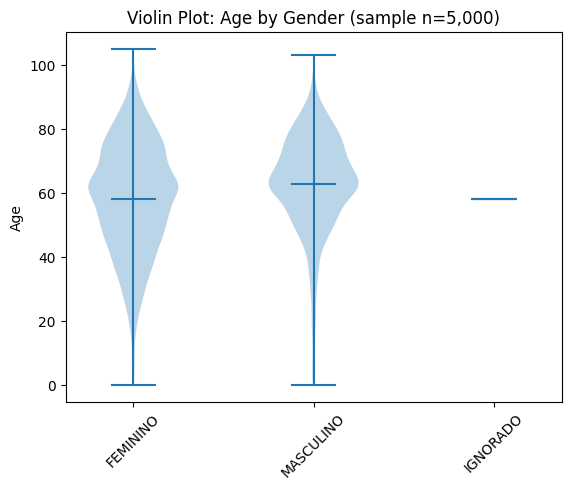

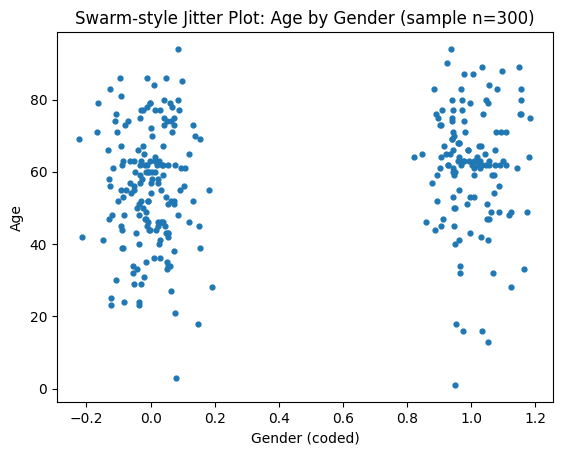

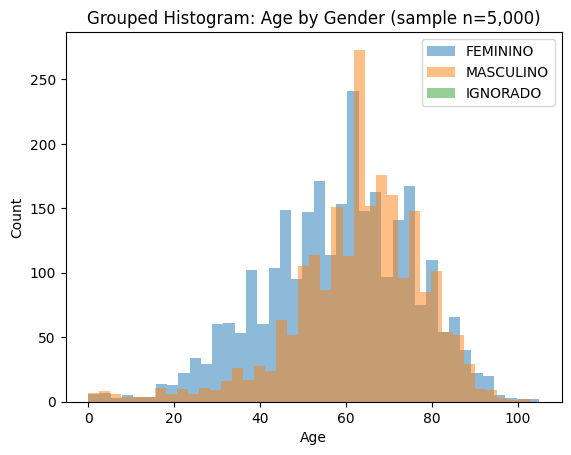

In [27]:
# Sample for speed 
sample5k = df_core.sample(n=5000, random_state=42)
tiny300 = df_core.sample(n=300, random_state=42)

# 1) KDE plot (Age)
plt.figure()
sample5k["Age"].plot(kind="kde")
plt.title("KDE of Age (sample n=5,000)")
plt.xlabel("Age")
plt.show()

# 2) Violin plot (Age by Gender)
plt.figure()
gender_order = sample5k["Gender"].value_counts().index.tolist()
data = [sample5k.loc[sample5k["Gender"] == g, "Age"]for g in gender_order]
plt.violinplot(data, showmeans=True)
plt.title("Violin Plot: Age by Gender (sample n=5,000)")
plt.xticks(range(1, len(gender_order)+1), gender_order, rotation=45)
plt.ylabel("Age")
plt.show()

# 3) Swarm-style jitter plot (Age by Gender) (tiny sample)
plt.figure()
x = tiny300["Gender"].astype("category").cat.codes
y = tiny300["Age"]
jitter = np.random.normal(0, 0.08, size=len(x))
plt.scatter(x + jitter, y, s=12)
plt.title("Swarm-style Jitter Plot: Age by Gender (sample n=300)")
plt.xlabel("Gender (coded)")
plt.ylabel("Age")
plt.show()

# 4) Grouped histogram (Age by Gender)
plt.figure()
for g in gender_order:
    plt.hist(sample5k.loc[sample5k["Gender"] == g, "Age"], bins=40, alpha=0.5, label=g)
plt.title("Grouped Histogram: Age by Gender (sample n=5,000)")
plt.xlabel("Age")
plt.ylabel("Count")
plt.legend()
plt.show()

The dataset was much larger than I expected, which made some operations quite slow. Because it’s so large, it’s also harder to immediately know what columns to drop, so focusing on a smaller set of columns for analysis is a practical and reasonable approach.

The Age distribution looks unimodal (one main peak) and it is not perfectly normal as it appears slightly right-skewed because the tail stretches toward older ages.

There are outliers in Age, mainly at the very high end (around 90–118) since those values are rare compared to the bulk of the data; however, after filtering unrealistic ages (e.g., >120, which I already cleaned), these remaining extremes are still plausible and not clearly data errors.

After cleaning, the Age values fall within a realistic range, with a minimum of about 0 and a maximum of about 118.

Changing bin sizes affects how the histogram looks: fewer bins (like 10) smooth the shape but can hide details, medium bins (like 30) balance detail and readability, and many bins (like 60) can make the plot look noisy; even so, the overall pattern (one peak with slight skew) stays consistent across bin choices.

In [28]:
df_core.to_csv("cleaned_cancer_data.csv", index=False)

# 4. Storytelling With Data graph

Reproduce any graph of your choice in p. 52-68 of the Storytelling With Data book as best you can.  (The second half of chapter two).  You do not have to get the exact data values right, just the overall look and feel.

In [27]:
data = {"Game": "Cricket"}
print(data)

{'Game': 'Cricket'}


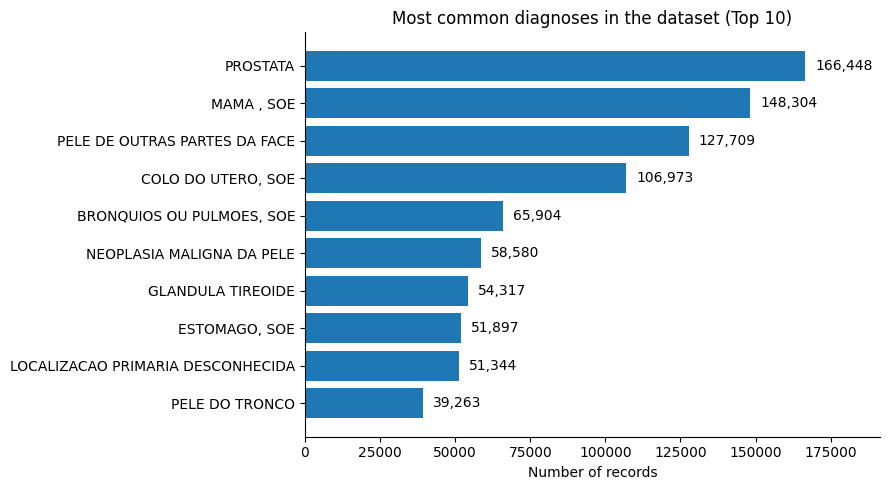

In [28]:
data = df_core_noNA if "df_core_noNA" in globals() else df_core

# Top 10 disease counts
top = data["Description.of.Disease"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(top.index, top.values)
ax.set_title("Most common diagnoses in the dataset (Top 10)")
ax.set_xlabel("Number of records")
ax.set_ylabel("")
ax.set_xlim(0, top.values.max() * 1.15)   

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Direct labels on bars
for i, v in enumerate(top.values):
    ax.text(v + (top.values.max() * 0.02), i, f"{v:,}", va="center")

plt.tight_layout()
plt.show()

I chose a horizontal bar chart because it’s the clearest way to compare category frequencies. 
I sorted the bars and used direct labels to make ranking and exact counts easy to read, while removing extra chart clutter to keep the focus on the main takeaway: a small number of diagnoses account for a large share of records.